<a href="https://colab.research.google.com/github/cara-jvr/mit-805-group-project/blob/unarine%2FMapReduce/Part_2_MapReduce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MIT 805 Big Data Project** <br>
Group 12 <br>
Unarine Ratshiedana (23985322)<br>
Cara Janse van Rensburg (18002189)

**1. Start-Up:** Creating Spark Session and importing required libraries

In [1]:
from pyspark.sql import SparkSession

# creating a Spark Session Object
spark = (
    SparkSession.builder
    .appName("Big-Data-Project")
    .master("local[*]")
    .config("spark.driver.memory", "10g")
    .getOrCreate()
)
sc = spark.sparkContext
spark

In [2]:
# import libraries
from pyspark.sql.functions import split, explode, col, desc, sum as _sum, when, count, to_timestamp, lit, datediff, timestamp_diff, unix_timestamp
from pyspark.sql import functions as F
import pyarrow.parquet as pq
import glob
import pandas as pd
import os
from google.colab import drive
import seaborn as sns
import matplotlib.pyplot as plt

**2. Loading the data**

In [3]:
# reading files from Google Drive
drive.mount('/content/drive')
file_path = "drive/MyDrive/Big_data_project/data"
os.listdir(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['fhvhv_tripdata_2021-04.parquet',
 'fhvhv_tripdata_2021-03.parquet',
 '.ipynb_checkpoints']

In [4]:
df = spark.read.parquet(file_path)

**3. Dataset Characteristics**

In [5]:
# Getting the column names and data types
df.printSchema()

root
 |-- hvfhs_license_num: string (nullable = true)
 |-- dispatching_base_num: string (nullable = true)
 |-- originating_base_num: string (nullable = true)
 |-- request_datetime: timestamp_ntz (nullable = true)
 |-- on_scene_datetime: timestamp_ntz (nullable = true)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- dropoff_datetime: timestamp_ntz (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- trip_time: long (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- tolls: double (nullable = true)
 |-- bcf: double (nullable = true)
 |-- sales_tax: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- tips: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- shared_request_flag: string (nullable = true)
 |-- shared_match_flag: string (nullable = true)
 |-- access_a_ride_f

In [6]:
# number of rows
rows = df.count()
print(f"Number of rows: {rows/10**6} million")

Number of rows: 28.338764 million


In [7]:
# size of compressed raw file
compressed_gb = 0

for root, dirs, files in os.walk(file_path):
    for file in files:
        if file.endswith(".parquet"):
            compressed_gb += os.path.getsize(os.path.join(root, file))

total_gb = compressed_gb / (1024**3)

print(f"Total dataset size: {total_gb:.2f} GB")

Total dataset size: 0.69 GB


In [8]:
# size of uncompressed raw file

def get_parquet_uncompressed_size(file_path):
  metadata = pq.read_metadata(file_path)
  total_bytes = sum(metadata.row_group(i).total_byte_size for i in range(metadata.num_row_groups))
  return total_bytes


total_uncompressed_bytes = 0
file_count = 0


for root, dirs, files in os.walk(file_path):
    for file in files:
        if file.endswith('.parquet') or file.endswith('.parq'):
            full_path = os.path.join(root, file)


            uncompressed_bytes = get_parquet_uncompressed_size(full_path)
            total_uncompressed_bytes += uncompressed_bytes
            file_count += 1
            size_in_gb = uncompressed_bytes / (1024 ** 3)

total_uncompressed_gb = total_uncompressed_bytes / (1024 ** 3)

print(f"Total Parquet Files Found: {file_count}")
print(f"Total Uncompressed Size:   {total_uncompressed_gb:.4f} GB")

Total Parquet Files Found: 2
Total Uncompressed Size:   1.2096 GB


In [9]:
df.limit(1).show()

+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+----+---------+--------------------+-----------+----+----------+-------------------+-----------------+------------------+----------------+--------------+
|hvfhs_license_num|dispatching_base_num|originating_base_num|   request_datetime|  on_scene_datetime|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tolls| bcf|sales_tax|congestion_surcharge|airport_fee|tips|driver_pay|shared_request_flag|shared_match_flag|access_a_ride_flag|wav_request_flag|wav_match_flag|
+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+----+---------+--------------------+-----------+--

In [10]:
#Data date range
df.select(
    F.min("pickup_datetime"),
    F.max("pickup_datetime")
).show()

+--------------------+--------------------+
|min(pickup_datetime)|max(pickup_datetime)|
+--------------------+--------------------+
| 2021-03-01 00:00:00| 2021-04-30 23:59:59|
+--------------------+--------------------+



**4. Data Quality Analysis & Data Cleaning**

In [11]:
#Missing Values
missing = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
])

missing.show()

+-----------------+--------------------+--------------------+----------------+-----------------+---------------+----------------+------------+------------+----------+---------+-------------------+-----+---+---------+--------------------+-----------+----+----------+-------------------+-----------------+------------------+----------------+--------------+
|hvfhs_license_num|dispatching_base_num|originating_base_num|request_datetime|on_scene_datetime|pickup_datetime|dropoff_datetime|PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tolls|bcf|sales_tax|congestion_surcharge|airport_fee|tips|driver_pay|shared_request_flag|shared_match_flag|access_a_ride_flag|wav_request_flag|wav_match_flag|
+-----------------+--------------------+--------------------+----------------+-----------------+---------------+----------------+------------+------------+----------+---------+-------------------+-----+---+---------+--------------------+-----------+----+----------+-------------------+-----

In [12]:
# dropping originating_base_num and on_scene_datetime columns
df = df.drop("originating_base_num", "on_scene_datetime")

In [13]:
# checking for duplicates
duplicates_df = (
    df.groupBy("hvfhs_license_num", "pickup_datetime", "dropoff_datetime","PULocationID", "DOLocationID", "trip_miles")
    .count()
    .filter(col("count") > 1)
)

duplicates_df.count()

77

In [14]:
duplicates_df.limit(1).show()

+-----------------+-------------------+-------------------+------------+------------+----------+-----+
|hvfhs_license_num|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_miles|count|
+-----------------+-------------------+-------------------+------------+------------+----------+-----+
|           HV0003|2021-04-12 01:52:59|2021-04-12 02:04:43|         256|         225|      3.09|    2|
+-----------------+-------------------+-------------------+------------+------------+----------+-----+



In [15]:
# dropping duplicates
df_dedup = df.dropDuplicates(["hvfhs_license_num", "pickup_datetime", "dropoff_datetime","PULocationID", "DOLocationID", "trip_miles"])
# dropping columns that are not needed
df_dedup = df_dedup.drop("dispatching_base_num", "request_datetime", "shared_request_flag", "shared_match_flag", "access_a_ride_flag")

In [16]:
# invalid Trip duration
df_dedup = df_dedup.withColumn(
    "trip_seconds",
     unix_timestamp(col("dropoff_datetime")) - unix_timestamp(col("pickup_datetime"))
)
df_dedup.filter(col("trip_seconds") <= 0).count()

396

In [17]:
# removing the above invalid trips
df_dedup = df_dedup.filter(col("trip_seconds") > 0)

In [18]:
# ensuring that trip_time corresponds to (dropoff_datetime - pickup_datetime) within 1 second
df_dedup = df_dedup.withColumn(
    "seconds_diff",
     (col("trip_time") - col("trip_seconds"))
)
df_dedup = df_dedup.withColumn("absolute_diff", F.abs(df_dedup["seconds_diff"]))
df_dedup.filter((col("absolute_diff")) >1).count()

13656

In [19]:
# removing more incorrect trip times
df_dedup = df_dedup.filter((col("absolute_diff")) <=1)

In [20]:
# base passenger fare must also be positive
df_dedup = df_dedup.filter(col("base_passenger_fare") > 0)

In [21]:
# dropping the above create columns, as they are not needed going further
df_dedup = df_dedup.drop("seconds_diff", "absolute_diff")

In [22]:
#df_dedup.describe().show()

In [23]:
# outliers (Using Interquartile Range method)
def IQR_outlier_removal(df, column_name):
  q1, q3 = df.approxQuantile(column_name, [0.25, 0.75], 0.05)
  iqr = q3 - q1
  lower_val = q1 - 1.5 * iqr
  upper_val = q3 + 1.5 * iqr
  clean_df = df.filter((col(column_name) >= lower_val) & (col(column_name) <= upper_val))
  return clean_df

df_clean1 = IQR_outlier_removal(df_dedup, "trip_time")

In [24]:
df_clean2 = IQR_outlier_removal(df_clean1, "trip_miles")
df_clean2.count()

24216770

In [25]:
# bias
# checking which pick-up locations are not attended to
PULocation_counts = df_clean2.groupBy("PULocationID").count()
PULocation_counts.orderBy(F.col("count").asc()).show(10)

+------------+-----+
|PULocationID|count|
+------------+-----+
|         199|    1|
|           1|    4|
|         105|    6|
|         110|   34|
|           2|   36|
|          99|  537|
|          27|  661|
|           8|  942|
|          30|  950|
|         111| 1003|
+------------+-----+
only showing top 10 rows


In [26]:
#checking which drop off zones are not get attended to
DOLocation_counts = df_clean2.groupBy("DOLocationID").count()
DOLocation_counts.orderBy(F.col("count").asc()).show(10)

+------------+-----+
|DOLocationID|count|
+------------+-----+
|         104|    1|
|         199|    2|
|         105|   10|
|         110|   59|
|           2|   60|
|           1|  254|
|          99|  648|
|          27|  905|
|          30|  947|
|           8|  954|
+------------+-----+
only showing top 10 rows


In [27]:
# check for operational time bias
df_clean2 = df_clean2.withColumn("Year", F.year("pickup_datetime")) \
              .withColumn("Month", F.month("pickup_datetime")) \
              .withColumn("Hour", F.hour("pickup_datetime")) \
              .withColumn("weekday_name", F.date_format("pickup_datetime", "EEEE"))

In [28]:
df_clean2.groupBy("weekday_name").count().orderBy("count", ascending=False).show()

+------------+-------+
|weekday_name|  count|
+------------+-------+
|      Friday|4018236|
|    Saturday|3783236|
|    Thursday|3626486|
|   Wednesday|3470047|
|     Tuesday|3233137|
|      Sunday|3055190|
|      Monday|3030438|
+------------+-------+



**5. Exploratory Data Analysis**

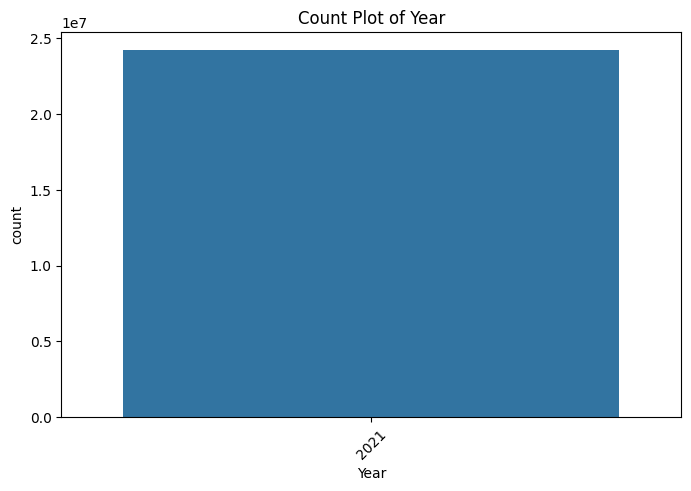

In [29]:
Year_df = df_clean2.groupBy("Year").count().toPandas()


plt.figure(figsize=(8, 5))
sns.barplot(x="Year", y="count", data=Year_df)
plt.title("Count Plot of Year")
plt.xticks(rotation=45)
plt.show()

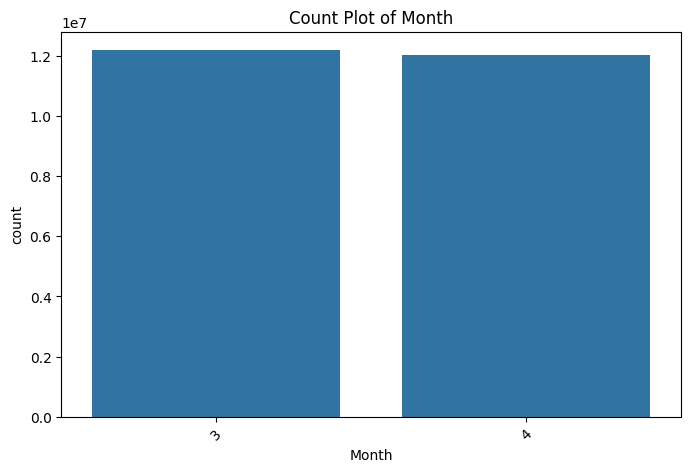

In [30]:
Month_df = df_clean2.groupBy("Month").count().toPandas()


plt.figure(figsize=(8, 5))
sns.barplot(x="Month", y="count", data=Month_df)
plt.title("Count Plot of Month")
plt.xticks(rotation=45)
plt.show()

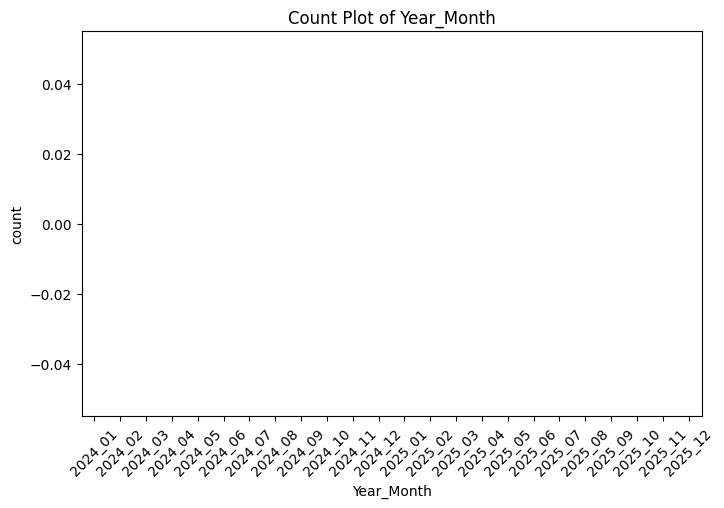

In [31]:
# year month
df_clean2 = df_clean2.withColumn(
    "Year_Month",
    F.concat_ws("_", F.col("Year"), F.lpad(F.col("Month"), 2, "0"))
)
Year_month_order = ["2024_01", "2024_02", "2024_03", "2024_04", "2024_05", "2024_06", "2024_07", "2024_08", "2024_09", "2024_10", "2024_11", "2024_12",
                    "2025_01", "2025_02", "2025_03", "2025_04", "2025_05", "2025_06", "2025_07", "2025_08", "2025_09", "2025_10", "2025_11", "2025_12"]
Year_Month_df = df_clean2.groupBy("Year_Month").count().toPandas()


plt.figure(figsize=(8, 5))
sns.barplot(x="Year_Month", y="count", data=Year_Month_df, order = Year_month_order)
plt.title("Count Plot of Year_Month")
plt.xticks(rotation=45)
plt.show()

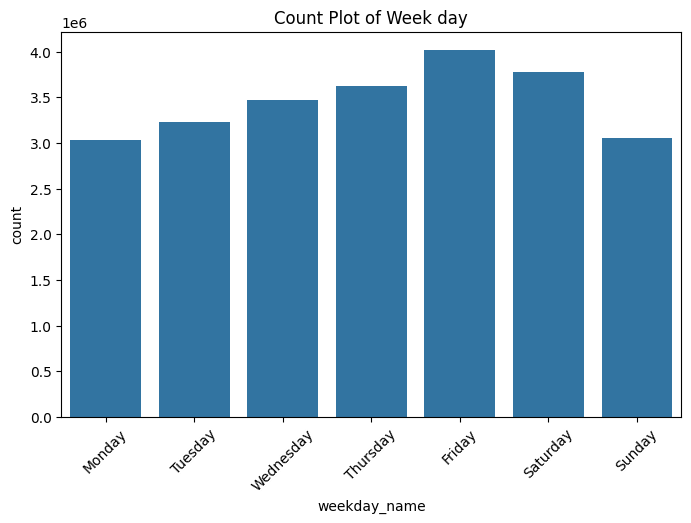

In [32]:
Day_df = df_clean2.groupBy("weekday_name").count().toPandas()
order_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(8, 5))
sns.barplot(x="weekday_name", y="count", data=Day_df, order=order_days)
plt.title("Count Plot of Week day")
plt.xticks(rotation=45)
plt.show()

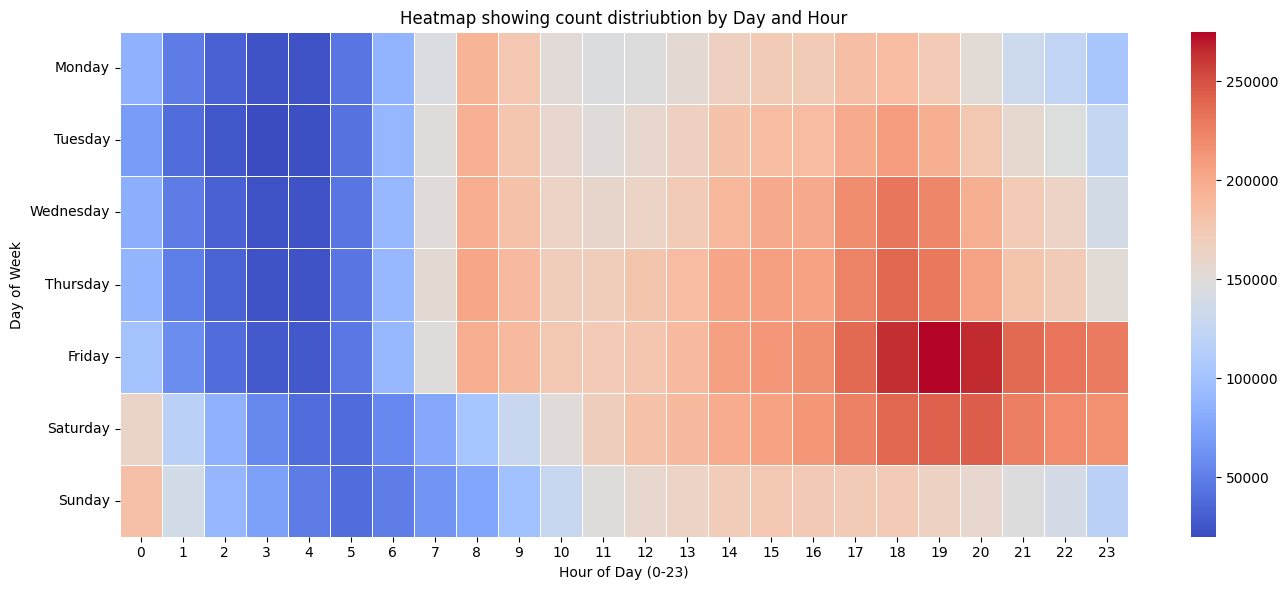

In [33]:
heatmap_df = df_clean2.groupBy("weekday_name", "Hour").count()

pandas = heatmap_df.toPandas()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

pandas["weekday_name"] = pd.Categorical(pandas["weekday_name"], categories=day_order, ordered=True)

pivot_df = pandas.pivot(index="weekday_name", columns="Hour", values="count").fillna(0)

plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot_df,
    cmap="coolwarm",
    annot=False,
    fmt="g",
    linewidths=0.5
)

plt.title("Heatmap showing count distriubtion by Day and Hour")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()


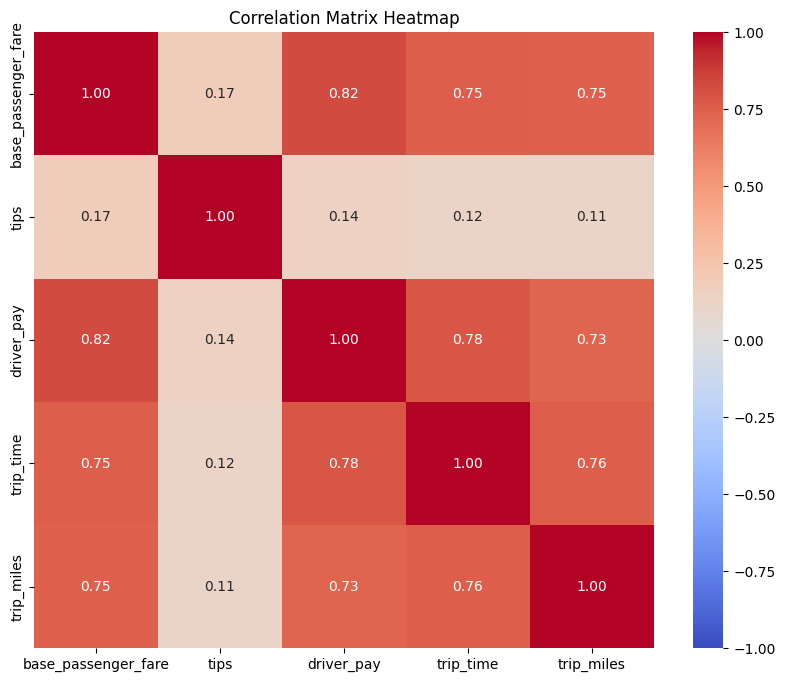

In [34]:
# correlation map
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

cols_corr = ["base_passenger_fare", "tips", "driver_pay", "trip_time", "trip_miles"]

assembler = VectorAssembler(inputCols=cols_corr, outputCol="features")
vector_df = assembler.transform(df_clean2).select("features")

mat = Correlation.corr(vector_df, "features").head()
spark_mat = mat[0].toArray()

corr_pd_df = pd.DataFrame(spark_mat, columns=cols_corr, index=cols_corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_pd_df, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()


## Part 2 Map reduce

In [35]:
# Mapping Phase
from pyspark.sql import functions as F

mapped_df = (
    df_clean2
    .withColumn("hour", F.hour("pickup_datetime"))
    .withColumn("weekday", F.date_format("pickup_datetime", "EEEE"))
    .select(
        "PULocationID",
        "base_passenger_fare",
        "trip_miles",
        "hour",
        "weekday"
    )
)

In [36]:
# Shuffle Phase
grouped_df = mapped_df.groupBy("PULocationID")

In [40]:
# Reduce Phase
location_summary = (
    grouped_df
    .agg(
        F.count("*").alias("total_trips"),
        F.sum("base_passenger_fare").alias("total_revenue"),
        F.avg("base_passenger_fare").alias("avg_fare"),
        F.avg("trip_miles").alias("avg_distance")
    )
)

## Spark Transformations and Actions

In [48]:
# Transformations
# withColumn()
# select()
# filter()
# groupBy()
# agg()
# orderBy()

In [49]:
# Actions
# how()
# count()
# collect()
# toPandas()

In [50]:
#Spark UI
location_summary.show()

+------------+-----------+------------------+------------------+------------------+
|PULocationID|total_trips|     total_revenue|          avg_fare|      avg_distance|
+------------+-----------+------------------+------------------+------------------+
|          26|     137497|1755687.2300000296|12.768912994465548|2.1378169850978557|
|          29|      50898| 646939.0800000046|12.710501002004099|  2.66228545325946|
|          65|      99737|2022444.6300000022|20.277776853123736|3.4842172313183686|
|         191|      64603| 926533.1900000102|14.341953005278551|3.4263761435227496|
|         222|      38057| 583352.3200000016|15.328384265706745|3.1235843603016544|
|         243|     151278|2492058.9600000083|16.473373259826335|3.4625071259535436|
|          19|      15442|230474.69999999995|14.925184561585285|3.9932337132495785|
|          54|      12793| 240329.9099999999| 18.78604783866176| 3.800145861017744|
|         155|      86260|1365592.6200000108|15.831122420589043| 3.164934569

In [51]:
# DAG Visualization
location_summary.explain(True)

== Parsed Logical Plan ==
'Aggregate ['PULocationID], ['PULocationID, 'count(*) AS total_trips#1469, 'sum('base_passenger_fare) AS total_revenue#1470, 'avg('base_passenger_fare) AS avg_fare#1471, 'avg('trip_miles) AS avg_distance#1472]
+- Project [PULocationID#7L, base_passenger_fare#11, trip_miles#9, hour#1455, weekday#1456]
   +- Project [hvfhs_license_num#0, pickup_datetime#5, dropoff_datetime#6, PULocationID#7L, DOLocationID#8L, trip_miles#9, trip_time#10L, base_passenger_fare#11, tolls#12, bcf#13, sales_tax#14, congestion_surcharge#15, airport_fee#16, tips#17, driver_pay#18, wav_request_flag#22, wav_match_flag#23, trip_seconds#397L, Year#876, Month#877, hour#1455, weekday_name#879, Year_Month#1133, date_format(cast(pickup_datetime#5 as timestamp), EEEE, Some(Etc/UTC)) AS weekday#1456]
      +- Project [hvfhs_license_num#0, pickup_datetime#5, dropoff_datetime#6, PULocationID#7L, DOLocationID#8L, trip_miles#9, trip_time#10L, base_passenger_fare#11, tolls#12, bcf#13, sales_tax#14, co

In [52]:
# Results and Technical Interpretation
top_locations = (
    location_summary
    .orderBy(F.desc("total_revenue"))
    .limit(10)
)

top_locations.show()

+------------+-----------+------------------+------------------+------------------+
|PULocationID|total_trips|     total_revenue|          avg_fare|      avg_distance|
+------------+-----------+------------------+------------------+------------------+
|          61|     422382| 6960603.629999772|16.479404022898162|2.6842358149731735|
|          79|     324662| 5738028.839999952| 17.67385416217467| 2.762461948118352|
|          76|     362960| 5343706.759999861|14.722577584306428| 2.913183185474982|
|          37|     296494| 5098224.519999923| 17.19503436831748|2.9215962717626716|
|          42|     291826| 4851309.949999933|16.623981242246863| 3.161003882450496|
|         231|     253598| 4816429.799999997| 18.99238085473859|3.0958449987775882|
|         225|     246070|4193631.0499999756| 17.04243121875879| 2.768629800463284|
|         255|     206187| 4162360.329999992|20.187307298714234| 3.442910241673822|
|          17|     249477|4104874.4999999725|16.453919599802678| 2.673080845

## Visualizations

<Axes: xlabel='PULocationID', ylabel='total_revenue'>

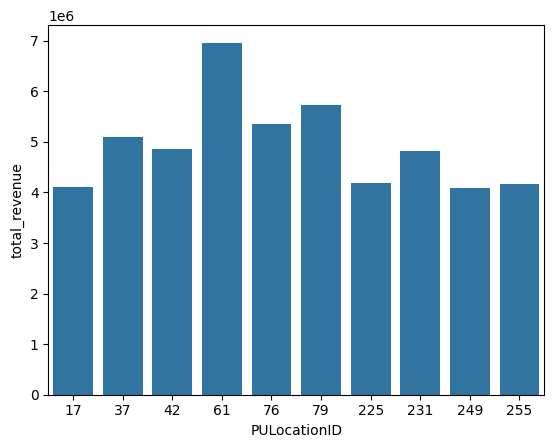

In [54]:
#Top 10 Revenue Generating Pickup Locations
top_locations_pd = top_locations.toPandas()

sns.barplot(
   data=top_locations_pd,
   x="PULocationID",
   y="total_revenue"
)

<Axes: xlabel='hour', ylabel='count'>

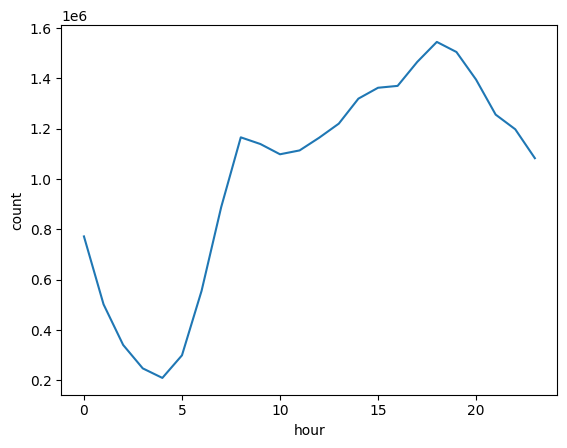

In [58]:
#Trips by Hour
hourly = (
    df_clean2
    .groupBy(F.hour("pickup_datetime").alias("hour"))
    .count()
    .orderBy("hour")
)

sns.lineplot(
    data=hourly.toPandas(),
    x="hour",
    y="count"
)

In [1]:
#Day vs Hour Heatmap
heatmap_df = df_clean2.groupBy("weekday_name", "Hour").count()

pandas = heatmap_df.toPandas()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

pandas["weekday_name"] = pd.Categorical(pandas["weekday_name"], categories=day_order, ordered=True)

pivot_df = pandas.pivot(index="weekday_name", columns="Hour", values="count").fillna(0)

plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot_df,
    cmap="coolwarm",
    annot=False,
    fmt="g",
    linewidths=0.5
)

plt.title("Heatmap showing count distriubtion by Day and Hour")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()


NameError: name 'df_clean2' is not defined

In [ ]:
#Revenue vs Distance Correlation
sns.scatterplot(
    data=df_clean2.sample(fraction=0.01, seed=42).toPandas(), # Sample 1% of the data, which is approximately 240,000 rows
    x="trip_miles",
    y="base_passenger_fare"
)